### Student Information
Name: 謝閔如

Student ID: u56134017

GitHub ID: Avery9990

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [3]:
# 導入必要的函式庫
import pandas as pd
import numpy as np
import nltk
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取Reddit
df = pd.read_csv('newdataset/Reddit-stock-sentiment.csv')

# 檢視資料集
print(df)
print(df.shape)
print(df.head())
print(df.info())

# 檢查缺失值
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# 標籤分布
print(df['label'].value_counts())

        type             datetime  post_id         subreddit  \
0    comment  2025-04-11 17:29:56  mmli62w    wallstreetbets   
1    comment   2025-04-12 1:12:19  mmnu7v9    wallstreetbets   
2    comment  2025-04-10 15:09:41  mmeevio       StockMarket   
3       post  2023-08-30 17:12:55  165kllm  stockstobuytoday   
4    comment  2025-04-11 14:48:05  mmkl6bw       StockMarket   
..       ...                  ...      ...               ...   
842  comment   2021-06-30 4:06:06  h3iv6pq  stockstobuytoday   
843  comment   2025-04-11 5:01:24  mmijiuz       StockMarket   
844     post  2025-03-24 12:30:39  1jipi4v  stockstobuytoday   
845  comment  2025-04-11 20:13:26  mmmely7    wallstreetbets   
846  comment   2025-04-12 3:09:06  mmobyz1    wallstreetbets   

                                                 title                author  \
0      Retardation is on the menu boys! WSB is so back          StickyTip420   
1    Retail giant TARGET has now declined for 10 co...  Comfortable-Dog

subreddit
stocks              274
StockMarket         250
stockstobuytoday    174
wallstreetbets      149
Name: count, dtype: int64


<Axes: title={'center': 'Category distribution'}, xlabel='subreddit'>

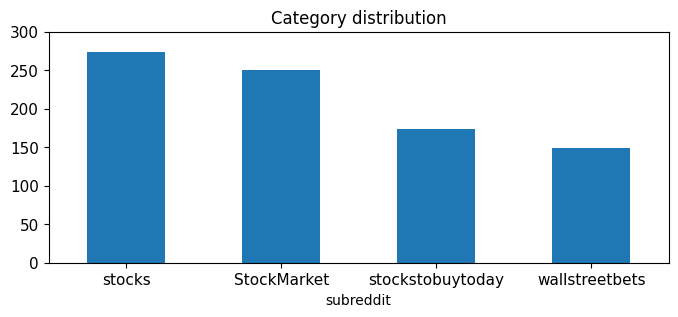

In [4]:
#subreddit以長條圖呈現
print(df.subreddit.value_counts())

df.subreddit.value_counts().plot(kind = 'bar',
                                    title = 'Category distribution',
                                    ylim = [0, 300],rot = 0, fontsize = 11, figsize = (8,3))

                  Data_Frame_1  Data_Frame_2
subreddit                                   
stocks                     169           274
StockMarket                136           250
stockstobuytoday           104           174
wallstreetbets              91           149


<Axes: title={'center': 'Category distribution'}, xlabel='subreddit'>

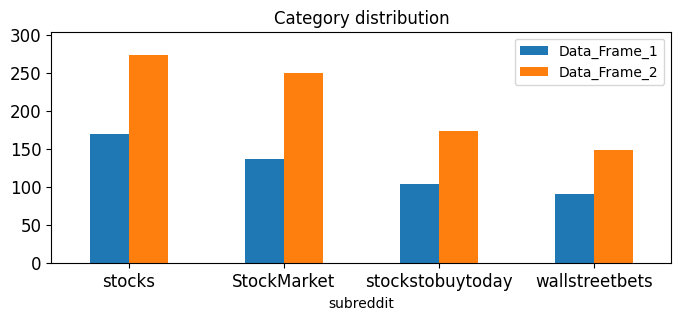

In [5]:
# 抽樣500筆數據進行比較
df_sample = df.sample(n=500)

dat_1 = df_sample.subreddit.value_counts()
dat_2 = df.subreddit.value_counts()
dat_combined = pd.DataFrame({
    'Data_Frame_1': dat_1,
    'Data_Frame_2': dat_2})
print(dat_combined)
dat_combined.plot(kind = 'bar',title = 'Category distribution',
                  ylim = [0, dat_combined.max().max()+30], 
                  rot = 0, fontsize = 12, figsize = (8,3))

In [6]:
# 文字轉向量
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
df_counts = count_vect.fit_transform(df.entities) 
print(df_counts)

  (np.int32(1), np.int32(1829))	1
  (np.int32(1), np.int32(408))	1
  (np.int32(1), np.int32(514))	1
  (np.int32(1), np.int32(1450))	1
  (np.int32(2), np.int32(1925))	1
  (np.int32(3), np.int32(2073))	1
  (np.int32(3), np.int32(1742))	1
  (np.int32(3), np.int32(1493))	3
  (np.int32(3), np.int32(738))	1
  (np.int32(3), np.int32(1214))	2
  (np.int32(3), np.int32(1199))	1
  (np.int32(3), np.int32(1865))	2
  (np.int32(3), np.int32(2048))	2
  (np.int32(3), np.int32(1893))	1
  (np.int32(3), np.int32(999))	2
  (np.int32(3), np.int32(2072))	2
  (np.int32(3), np.int32(1577))	1
  (np.int32(3), np.int32(1953))	1
  (np.int32(3), np.int32(1412))	1
  (np.int32(3), np.int32(1709))	1
  (np.int32(3), np.int32(1366))	2
  (np.int32(3), np.int32(389))	1
  (np.int32(3), np.int32(1018))	1
  (np.int32(3), np.int32(1655))	1
  (np.int32(3), np.int32(1471))	1
  :	:
  (np.int32(836), np.int32(1435))	1
  (np.int32(836), np.int32(811))	1
  (np.int32(836), np.int32(1372))	2
  (np.int32(837), np.int32(1852))	1
  (np.

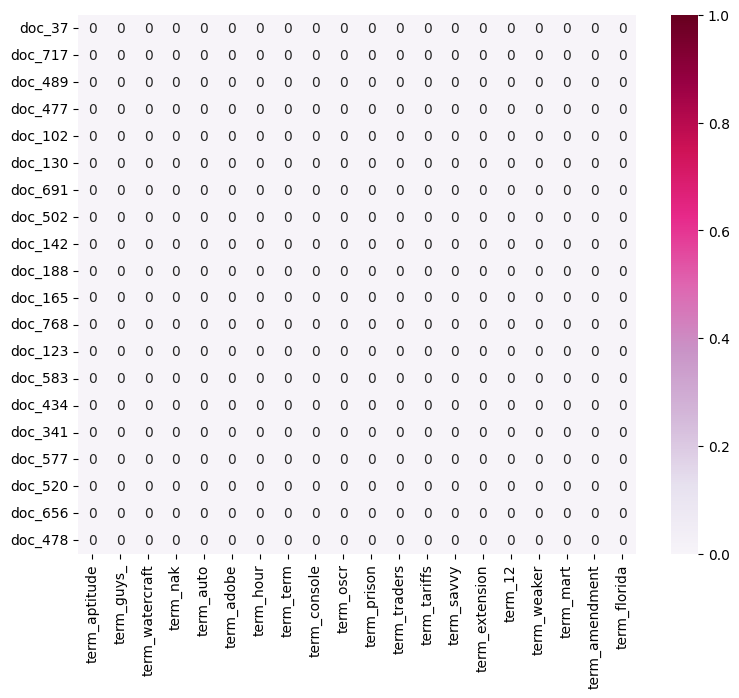

In [7]:
import random
all_terms = list(range(df_counts.shape[1]))
all_docs_idx = list(range(df_counts.shape[0]))

# 隨機抽20個term index與document index
picked_terms = random.sample(all_terms, 20)
picked_docs_idx = random.sample(all_docs_idx, 20)

#存成名稱
terms = count_vect.get_feature_names_out()
picked_terms_1 = [terms[i] for i in picked_terms]
plot_x_rdm = ["term_" + str(i) for i in picked_terms_1]

plot_y_rdm = ["doc_" + str(i) for i in picked_docs_idx]

plot_z_rdm = df_counts[picked_docs_idx, :][:, picked_terms].toarray()

# 建立DataFrame
df_todraw = pd.DataFrame(plot_z_rdm, columns=plot_x_rdm, index=plot_y_rdm)

# Plot
plt.subplots(figsize=(9, 7))
ax = sns.heatmap(df_todraw,
                 cmap="PuRd",
                 vmin=0, vmax=1, annot=True)
plt.show()


C:\Users\hsieh\AppData\Local\Temp\ipykernel_27620\3599406256.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);


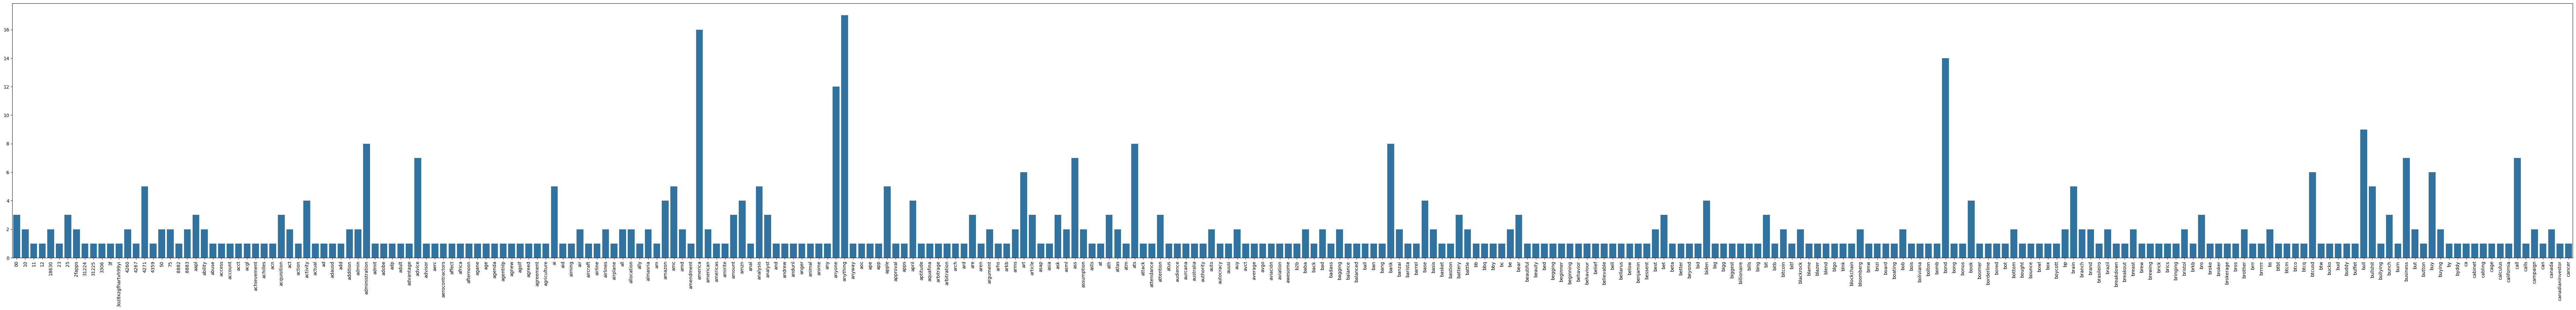

In [8]:
term_frequencies = []
for j in range(0,df_counts.shape[1]):
    term_frequencies.append(sum(df_counts[:,j].toarray()))

term_frequencies = np.asarray(df_counts.sum(axis=0))[0]
plt.subplots(figsize=(100, 10))
g = sns.barplot(x=count_vect.get_feature_names_out()[:300], 
            y=term_frequencies[:300])
g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);

# Phase 2

In [11]:
print(df.columns)


Index(['type', 'datetime', 'post_id', 'subreddit', 'title', 'author', 'url',
       'upvotes', 'downvotes', 'upvote_ratio', 'text', 'subjectivity',
       'polarity', 'sentiment', 'entities', 'label'],
      dtype='object')


In [12]:
### Begin Assignment Here

import re, math, itertools, numpy as np, pandas as pd
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier
from scipy.sparse import csr_matrix, hstack

RANDOM_STATE = 42


TEXT_COL  = 'text'
LABEL_COL = 'label'          
# 分類的數字標籤，若你用 'category_name' 也行


# ---- 類別名稱對照
def build_target_names(df, label_col='category'):
    if 'category_name' in df.columns:
        mp = dict(df[[label_col, 'category_name']].drop_duplicates().values)
        return [mp[k] for k in sorted(mp.keys())]
    else:
        # fallback：用排序後的類別代號
        return [str(k) for k in sorted(df[label_col].unique())]

target_names_main = build_target_names(df, LABEL_COL)


In [16]:
# =========================================================
# 1) Finding frequent patterns → pattern_matrix → Naive Bayes（主資料集）
# =========================================================

# -- Tokenizer 保留英文與數字
TOKEN_PATTERN = re.compile(r"[A-Za-z0-9_]+")  # 英數 token

def tokenize(s):
    return TOKEN_PATTERN.findall(str(s).lower())

# 建立 tokens 
df_tokens = df[TEXT_COL].apply(tokenize)
df_token_sets = df_tokens.apply(set)


count_vect = CountVectorizer(token_pattern=r"[A-Za-z0-9_]+", lowercase=True)
tdm = count_vect.fit_transform(df[TEXT_COL])     # 稀疏矩陣
tdm_df = pd.DataFrame.sparse.from_spmatrix(tdm, columns=count_vect.get_feature_names_out())


def mine_frequent_itemsets(token_sets, min_support=0.02, max_k=2):
    # min_support 
    N = len(token_sets)
    support_threshold = math.ceil(min_support * N)
    # 先做 unigram 檢索
    unigram_counts = Counter()
    for s in token_sets:
        for t in s:
            unigram_counts[t] += 1
    # 篩選出頻繁 unigram
    frequent_1 = { (w,): c for w,c in unigram_counts.items() if c >= support_threshold }

    results = dict(frequent_1)

    if max_k >= 2:
        bigram_counts = Counter()
        for s in token_sets:
            for a,b in itertools.combinations(sorted(s), 2):
                bigram_counts[(a,b)] += 1
        frequent_2 = { k:c for k,c in bigram_counts.items() if c >= support_threshold }
        results.update(frequent_2)

    if max_k >= 3:
        trigram_counts = Counter()
        for s in token_sets:
            for a,b,c in itertools.combinations(sorted(s), 3):
                trigram_counts[(a,b,c)] += 1
        support_3 = { k:c for k,c in trigram_counts.items() if c >= support_threshold }
        results.update(support_3)

    # 轉成 DataFrame：Patterns
    pat_df = (
        pd.DataFrame(
            [(k, v) for k,v in results.items()],
            columns=['Pattern', 'DocCount']
        )
        .sort_values('DocCount', ascending=False)
        .reset_index(drop=True)
    )
    pat_df['Support'] = pat_df['DocCount'] / N
    return pat_df

# ---- 開挖
final_pattern_df = mine_frequent_itemsets(df_token_sets, min_support=0.02, max_k=2)
final_pattern_df.head(10)


,Pattern,DocCount,Support
0,"(the,)",363,0.428571
1,"(to,)",302,0.356553
2,"(and,)",260,0.306966
3,"(a,)",259,0.305785
4,"(is,)",247,0.291617
5,"(it,)",228,0.269185
6,"(i,)",206,0.243211
7,"(the, to)",200,0.236128
8,"(of,)",188,0.221960
9,"(in,)",180,0.212515


In [18]:
# ---- 將 frequent patterns 轉成二元特徵矩陣 pattern_matrix（每列一篇文件、每欄一個 pattern）----
def build_pattern_matrix(token_lists, pattern_df):
    patterns = pattern_df['Pattern'].tolist()
    n_docs = len(token_lists)
    n_pats = len(patterns)
    indptr = [0]
    indices, data = [], []
    # 用 set 加速包含判斷
    token_sets = [set(ts) for ts in token_lists]

    for i, s in enumerate(token_sets):
        for j, pat in enumerate(patterns):
            # 若 pattern（tuple）全部包含於該文件 tokens
            if all(p in s for p in pat):
                indices.append(j)
                data.append(1)
        indptr.append(len(indices))
    # CSR 稀疏矩陣
    mat = csr_matrix((data, indices, indptr), shape=(n_docs, n_pats), dtype=np.int8)
    return mat, patterns

pattern_matrix_csr, pattern_list = build_pattern_matrix(df_tokens.tolist(), final_pattern_df)
pattern_df = pd.DataFrame.sparse.from_spmatrix(
    pattern_matrix_csr, columns=[ "PAT__" + "_".join(p) for p in pattern_list]
)
pattern_df.head(5)


,PAT__the,PAT__to,PAT__and,PAT__a,PAT__is,PAT__it,PAT__i,PAT__the_to,PAT__of,PAT__in,...,PAT__doing_is,PAT__doing_the,PAT__i_out,PAT__the_way,PAT__and_don,PAT__an_on,PAT__anything,PAT__a_company,PAT__and_get,PAT__a_get
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,1,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
# ---- Augmentation：TDM + pattern_matrix ----
X_aug = pd.concat([tdm_df, pattern_df], axis=1)
y_main = df[LABEL_COL]

# ---- Naive Bayes----
def run_nb(Xfeat, y, target_names, title):
    X_train, X_test, y_train, y_test = train_test_split(
        Xfeat, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
    )
    nb = MultinomialNB()
    nb.fit(X_train, y_train)
    y_pred = nb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"[NB] {title} — Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4))
    return acc

acc_nb_tdm = run_nb(tdm_df, y_main, target_names_main, "TDM only")
acc_nb_aug = run_nb(X_aug,   y_main, target_names_main, "Augmented (TDM + Patterns)")


[NB] TDM only — Accuracy: 0.5569
              precision    recall  f1-score   support

        -1.0     0.5180    0.7579    0.6154        95
         0.0     0.6481    0.5512    0.5957       127
         1.0     0.0000    0.0000    0.0000        33

    accuracy                         0.5569       255
   macro avg     0.3887    0.4364    0.4037       255
weighted avg     0.5158    0.5569    0.5260       255

[NB] Augmented (TDM + Patterns) — Accuracy: 0.5216
              precision    recall  f1-score   support

        -1.0     0.5126    0.6421    0.5701        95
         0.0     0.6034    0.5512    0.5761       127
         1.0     0.1000    0.0606    0.0755        33

    accuracy                         0.5216       255
   macro avg     0.4054    0.4180    0.4072       255
weighted avg     0.5045    0.5216    0.5091       255



In [29]:

def pipeline_run(df, name="NEW_DATA", text_col=TEXT_COL, label_col=LABEL_COL,
                 min_support=0.02, max_k=2):
    print(f"\n================= PIPELINE on {name} =================")
    target_names = build_target_names(df, label_col)
    tokens = df[text_col].apply(tokenize)
    token_sets = tokens.apply(set)

    # TDM
    cv = CountVectorizer(token_pattern=r"[A-Za-z0-9_]+", lowercase=True)
    tdm_m = cv.fit_transform(df[text_col])
    tdm_df_local = pd.DataFrame.sparse.from_spmatrix(tdm_m, columns=cv.get_feature_names_out())

    # Frequent Patterns
    pat_df_local = mine_frequent_itemsets(token_sets, min_support=min_support, max_k=max_k)
    pat_csr_local, pat_list = build_pattern_matrix(tokens.tolist(), pat_df_local)
    pat_df_bin = pd.DataFrame.sparse.from_spmatrix(
        pat_csr_local, columns=["PAT__" + "_".join(p) for p in pat_list]
    )

    # Augmentation
    X_aug_local = pd.concat([tdm_df_local, pat_df_bin], axis=1)
    y_local = df[label_col]

    # NB: TDM vs Aug
    acc_tdm = run_nb(tdm_df_local, y_local, target_names, f"{name} – TDM only")
    acc_aug = run_nb(X_aug_local,   y_local, target_names, f"{name} – Augmented")

    return {
        "tdm_df": tdm_df_local, "pattern_df": pat_df_bin,
        "acc_nb_tdm": acc_tdm, "acc_nb_aug": acc_aug,
        "target_names": target_names
    }




In [32]:
# =========================================================
# 3) TF-IDF features + Naive Bayes

def run_tfidf_nb(df, name="DATASET", text_col=TEXT_COL, label_col=LABEL_COL,
                 tokens=None, pattern_df=None, target_names=None):
    print(f"\n================= TF-IDF NB on {name} =================")
    y = df[label_col]
    if target_names is None:
        target_names = build_target_names(df, label_col)
    # TF-IDF
    tfidf = TfidfVectorizer(token_pattern=r"[A-Za-z0-9_]+", lowercase=True)
    X_tfidf = tfidf.fit_transform(df[text_col])

    # MultinomialNB on TF-IDF
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_tfidf, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
    )
    nb = MultinomialNB()
    nb.fit(X_tr, y_tr)
    y_hat = nb.predict(X_te)
    acc_mnb = accuracy_score(y_te, y_hat)
    print(f"[TF-IDF + MultinomialNB] Accuracy: {acc_mnb:.4f}")
    print(classification_report(y_te, y_hat, target_names=target_names, digits=4))

    # ComplementNB（對不平衡較穩定）
    cnb = ComplementNB()
    cnb.fit(X_tr, y_tr)
    y_hat_c = cnb.predict(X_te)
    acc_cnb = accuracy_score(y_te, y_hat_c)
    print(f"[TF-IDF + ComplementNB] Accuracy: {acc_cnb:.4f}")
    print(classification_report(y_te, y_hat_c, target_names=target_names, digits=4))

    # Augment with patterns if provided（把 pattern_df 拼回 TF-IDF）
    if pattern_df is not None:
        # 將 pattern 稀疏矩陣與 TF-IDF 稀疏矩陣水平拼接
        X_aug = hstack([X_tfidf, csr_matrix(pattern_df.sparse.to_coo())], format='csr')
        X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
            X_aug, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
        )
        nb2 = MultinomialNB()
        nb2.fit(X_tr2, y_tr2)
        y_hat2 = nb2.predict(X_te2)
        print(f"[TF-IDF + Patterns + MNB] Accuracy: {accuracy_score(y_te2, y_hat2):.4f}")
        print(classification_report(y_te2, y_hat2, target_names=target_names, digits=4))

        cnb2 = ComplementNB()
        cnb2.fit(X_tr2, y_tr2)
        y_hat2c = cnb2.predict(X_te2)
        print(f"[TF-IDF + Patterns + CNB] Accuracy: {accuracy_score(y_te2, y_hat2c):.4f}")
        print(classification_report(y_te2, y_hat2c, target_names=target_names, digits=4))


run_tfidf_nb(
    df, name="MAIN_DATASET",
    pattern_df=pattern_df, target_names=target_names_main
)





================= TF-IDF NB on MAIN_DATASET =================
[TF-IDF + MultinomialNB] Accuracy: 0.5804
              precision    recall  f1-score   support

        -1.0     0.6379    0.3895    0.4837        95
         0.0     0.5635    0.8740    0.6852       127
         1.0     0.0000    0.0000    0.0000        33

    accuracy                         0.5804       255
   macro avg     0.4005    0.4212    0.3896       255
weighted avg     0.5183    0.5804    0.5214       255

[TF-IDF + ComplementNB] Accuracy: 0.4980
              precision    recall  f1-score   support

        -1.0     0.4924    0.6842    0.5727        95
         0.0     0.6040    0.4803    0.5351       127
         1.0     0.0455    0.0303    0.0364        33

    accuracy                         0.4980       255
   macro avg     0.3806    0.3983    0.3814       255
weighted avg     0.4901    0.4980    0.4846       255

[TF-IDF + Patterns + MNB] Accuracy: 0.5294
              precision    recall  f1-score   sup

c:\桌面\COADING\Python\data_mining\DM2025Labs\DM2025-Lab1-Exercise\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\桌面\COADING\Python\data_mining\DM2025Labs\DM2025-Lab1-Exercise\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\桌面\COADING\Python\data_mining\DM2025Labs\DM2025-Lab1-Exercise\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter t